# CoCiP Implementation for Comparison to APCEMM

In [14]:
# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from pycontrails import Flight
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.models.cocip import Cocip
from pycontrails.models.humidity_scaling import ConstantHumidityScaling
from pycontrails.physics import units
from pycontrails import MetDataset

In [15]:
test_id = "110T218L25"
save_data = False

# Set the aircraft and flight parameters to match LES simulations

## Make CSV if needed

In [16]:
def ice_particle_activation_rate(air_temperature, T_crit_sac):
    d_temp = air_temperature - T_crit_sac
    if d_temp > 0.0:
        d_temp = 0.0
    if d_temp < -5.0:
        d_temp = float('-inf')
    return -0.661 * np.exp(d_temp) + 1.0

def T_sat_liquid(G):
    G_log = np.log(G - 0.053)
    T_LM = (-46.46 + 9.43 * G_log + 0.72 * G_log**2) + 273.15 # Convert to K
    return T_LM

def estimate_specific_humidity(air_temperature, air_pressure, rh):
    air_temperature_celsius = units.kelvin_to_celsius(air_temperature)
    exponent = (7.5 * air_temperature_celsius) / (237.3 + air_temperature_celsius)
    P_sat = 6.107 * 10 ** exponent  # Saturation vapor pressure, hPa
    air_pressure_hpa = air_pressure / 100
    numer = 0.62197058 * rh * P_sat
    denom = air_pressure_hpa - rh * P_sat
    return numer / denom

In [17]:
make_csv = False  # Set to True to create the CSV file

# Dictionary mapping test_id to a tuple of (N, f_surv)
test_params = {
    "110T205L25": (3.58e12, 0.937109),
    "110T218L25": (9.47e11, 0.776528),
    "110T225L25": (5.88e11, 0.786246*0.57866),
    "130T205L25": (4.90563e12, 0.94893),
    "130T218L25": (2.42845e12, 0.880234),
    "130T225L25": (1.78821e12, 0.861311*0.69728),
    # Add more test_id: (N, f_surv) pairs as needed
}

# Get N and f_surv for the current test_id
N, f_surv = test_params.get(test_id)  # Defaults if test_id not in dictionary

if make_csv == True:
    # Update the CSV file with B767 characteristics
    df_flight = pd.read_csv("flight-cocip-aligned.csv")

    altitude = 10700.0 # [m]
    df_flight["Altitude (m)"] = altitude # Set altitude to 10.7 km

    u = 237  # Set true airspeed to 237 m/s
    df_flight["True airspeed (m s-1)"] = u

    # Calculate the mach number
    gamma = 1.4  # Specific heat ratio for air at 10.7 km
    T = float(test_id[4:7])  # Temperature at 10.7 km in Kelvin, e.g., "205" from "110T205L25"
    R = 286.9  # Specific gas constant for dry air in J/(kg·K)
    a = np.sqrt(gamma*R*T)  # Speed of sound at 10.7 km
    M = df_flight["True airspeed (m s-1)"] / a  # Speed of sound at 10.7 km
    df_flight["Mach Number"] = M  # Set Mach number

    # Calculate the initial EInvpm to match the LLES values after vortex sinking
    efficiency = 0.3
    epsilon = 0.622 # Ratio of molecular weights of dry air and water vapor
    q_fuel = 43e6 # Specific heat of combustion [J/kg]
    ei_h2o = 1.24 # emission index of water vapor [kg/kg]
    air_pressure = lib.alt2press(altitude) # [Pa]
    c_pd = 1005 # Specific heat of dry air
    c_pv = 1850 # Specific heat of water vapor
    RH = float(test_id[0:3])/100 # Fraction of RHi
    q = estimate_specific_humidity(T, air_pressure, RH) # Specific humidity
    c_pm = c_pd * (1 - q) + c_pv * q # Specific heat capacity of moist air
    G = (ei_h2o * c_pm * air_pressure) / (epsilon * q_fuel * (1 - efficiency)) # Slope of SAC
    T_LM = T_sat_liquid(G) # [K]
    print(f"The liquid water temperature is {T_LM}")
    activation_rate = ice_particle_activation_rate(T, T_LM)
    print(f"The activation rate is {activation_rate}")
    mdot_f = 1.36986 # Estimated using cruise velocity and fuel flow rate from Lewellen et al. (2014) [kg/s]
    EI_nvpm = (N*u)/(mdot_f*f_surv*activation_rate)

    df_flight["Aircraft mass (kg)"] = 152281.72  # At beginning of cruise (35k ft) for B767-300 (uses Trent 4000, same as all B767 models)
    df_flight["Fuel mass flow rate (kg s-1)"] = mdot_f
    df_flight["Overall propulsion efficiency"] = efficiency  # Set overall propulsion efficiency to 30%
    df_flight["nvPM number emissions index (kg-1)"] = EI_nvpm # Number per kg fuel
    df_flight["ICAO Aircraft Type"] = "B767"
    df_flight["Wingspan (m)"] = 47.25 # Set wingspan to 47.25 m

    # Calculate the UTC time in seconds for 2023-01-01 00:00:00 at 60 second intervals
    df_flight["UTC time"] = pd.date_range(start="2023-01-01 00:00:00", periods=len(df_flight), freq="60s").astype(np.int64) // 10**9
    df_flight["time"] = pd.to_datetime(df_flight["UTC time"], origin="unix", unit="s") # Convert the UTC time to datetimes and assign to the "time" column

    # Save the updated DataFrame to a new CSV file
    df_flight.to_csv(f"{test_id}/{test_id}-flight-cocip-aligned.csv", index=False, mode="w")

## Load and format the flight data CSV

In [18]:
df_flight = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-flight-cocip-aligned.csv")

# constant properties along the length of the flight
attrs = {
    "flight_id": "fid",
    "aircraft_type": df_flight["ICAO Aircraft Type"].values[0],
    "wingspan": df_flight["Wingspan (m)"].values[0]
}

# rename a few columns for compatibility with `Flight` requirements
df_flight = df_flight.rename(
    columns={
        "Longitude (degrees)": "longitude",
        "Latitude (degrees)": "latitude",
        "True airspeed (m s-1)": "true_airspeed",
        "Mach Number": "mach_number",
        "Aircraft mass (kg)": "aircraft_mass",
        "Fuel mass flow rate (kg s-1)": "fuel_flow",
        "Overall propulsion efficiency": "engine_efficiency",
        "nvPM number emissions index (kg-1)": "nvpm_ei_n",
        "Altitude (m)": "altitude",
    }
)

# clean up a few columns before building Flight class
df_flight = df_flight.drop(
    columns=["ICAO Aircraft Type", "Wingspan (m)", "UTC time"]
)

fl = Flight(data=df_flight, attrs=attrs)
fl

Flight [11 keys x 162 length, 3 attributes]
	Keys: longitude, latitude, Altitude (feet), true_airspeed, mach_number, ..., time
	Attributes:
	time                [2023-01-01 00:00:00, 2023-01-01 02:41:00]
	longitude           [-50.0, -10.07]
	latitude            [55.0, 55.0]
	altitude            [10700.0, 10700.0]
	flight_id           fid
	aircraft_type       B767
	wingspan            47.25

# Download radiation data from ERA5

In [19]:
# get met and rad domain from Flight
time = (
    pd.to_datetime(fl["time"][0]).floor("h"),
    pd.to_datetime(fl["time"][-1]).ceil("h") + pd.Timedelta("80h"),
)
# Download radiation data from ERA5
era5sl = ERA5(time=time, variables=Cocip.rad_variables)

# Create new meteorology to match LES simulations

In [20]:
# create `MetDataset` from sources
rad = era5sl.open_metdataset()

In [21]:
met_from_scratch = False  # Set to True to create the met dataset from scratch

if met_from_scratch:
    # Make the met file

    # Import APCEMM met data
    xr_apcemm_met = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/full_runs/{test_id}/{test_id}.nc")

    # Define dimensions
    longitudes = np.linspace(-180, 179.75, int((180+179.75)/(0.25) + 1))

    latitudes = np.linspace(30, 70, int((70-30)/(0.25) + 1))
    levels = np.flip(xr_apcemm_met['pressure'].values)

    UTC = pd.date_range(start="2023-01-01 00:00:00", periods=60, freq="1h").astype(np.int64) // 10**9
    time = pd.to_datetime(UTC, origin="unix", unit="s") # Convert the UTC time to datetimes and assign to the "time" column

    # Define the additional coordinates to add
    altitudes = np.flip((xr_apcemm_met['altitude'].values).astype(np.float32)) * 1000  # Convert altitude from km to m
    pressures = levels * 100  # Convert pressure from hPa to Pa

    # Define the shpae of the dataset
    new_shape = (len(longitudes), len(latitudes), len(levels), len(time))

    # Create the data to be saved in the new dataset (variables)
    air_temperature = np.broadcast_to(
        np.flip(xr_apcemm_met['temperature'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)

    relative_humidity = np.broadcast_to(
        np.flip(xr_apcemm_met['relative_humidity_ice'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)

    northward_wind = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, only horizontal shearing
    lagrangian_tendency_of_air_pressure = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, no downward motion
    specific_cloud_ice_water_content = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, no cloud cover

    # Calculate the specific humidity based on RHi and temperature
    T0 = 273.15  # Reference temperature in Kelvin
    T_base = air_temperature[0,0,:,0] # Temperature in Kelvin
    RHi_base = relative_humidity[0,0,:,0]
    pres_base = levels * 100  # Pressure in Pa
    P_sat_w = lib.compute_Psat_w(T_base)
    P_sat_i = lib.compute_Psat_i(T_base)
    q_base = (RHi_base * P_sat_i / P_sat_w) * (1 / (0.263 * pres_base)) * np.exp((17.67 * (T_base - T0)) / (T_base - 29.65))
    specific_humidity = np.broadcast_to(
            q_base[np.newaxis, np.newaxis, :, np.newaxis],  # lon, lat, level, time
            new_shape
        ).astype(np.float32)

    # Calculate the wind feild for constant shear of 0.004 m/s/m
    slope = 0.004  # m/s/m
    u = slope * levels
    eastward_wind = np.broadcast_to(
            u[np.newaxis, np.newaxis, :, np.newaxis],  # lon, lat, level, time
            new_shape
        ).astype(np.float32)

    # Create dataset with the variables and coordinates defined above
    ds_met = xr.Dataset(
        {
            "air_temperature": (['longitude', 'latitude', 'level', 'time'], air_temperature),
            "specific_humidity": (['longitude', 'latitude', 'level', 'time'], specific_humidity),
            "eastward_wind": (['longitude', 'latitude', 'level', 'time'], eastward_wind),
            "northward_wind": (['longitude', 'latitude', 'level', 'time'], northward_wind),
            "lagrangian_tendency_of_air_pressure": (['longitude', 'latitude', 'level', 'time'], lagrangian_tendency_of_air_pressure),
            "specific_cloud_ice_water_content": (['longitude', 'latitude', 'level', 'time'], specific_cloud_ice_water_content),
            "relative_humidity": (['longitude', 'latitude', 'level', 'time'], relative_humidity),

        },
        coords={
            'longitude': longitudes,
            'latitude': latitudes,
            'level': levels,
            'time': time,
            'altitude': ('level', altitudes),
            'air_pressure': ('level', pressures)
        },
        attrs=None
    )

    # Save the modified xr_met to a new NetCDF file
    ds_met.to_netcdf(f"{test_id}-met.nc", mode="w", format="NETCDF4")

else:
    # Load in the existing met file
    ds_met = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-met.nc", )

In [22]:
ds_met

<xarray.Dataset> Size: 49GB
Dimensions:                              (longitude: 1440, latitude: 161,
                                          level: 125, time: 60)
Coordinates:
  * longitude                            (longitude) float64 12kB -180.0 ... ...
  * latitude                             (latitude) float64 1kB 30.0 ... 70.0
  * level                                (level) float64 1kB 181.5 ... 1.013e+03
  * time                                 (time) datetime64[ns] 480B 2023-01-0...
    altitude                             (level) float32 500B ...
    air_pressure                         (level) float64 1kB ...
Data variables:
    air_temperature                      (longitude, latitude, level, time) float32 7GB ...
    specific_humidity                    (longitude, latitude, level, time) float32 7GB ...
    eastward_wind                        (longitude, latitude, level, time) float32 7GB ...
    northward_wind                       (longitude, latitude, level, time) float32 7GB ...
    lagrangian_tendency_of_air_pressure  (longitude, latitude, level, time) float32 7GB ...
    specific_cloud_ice_water_content     (longitude, latitude, level, time) float32 7GB ...
    relative_humidity                    (longitude, latitude, level, time) float32 7GB ...

## Plot the meteorological input variables

In [23]:
# Select the first longitude, latitude, and time index
rh_profile = ds_met["relative_humidity"].isel(longitude=0, latitude=0, time=0)
altitudes = ds_met["altitude"].values

# Find indices where altitude is between 11000 and 10000 meters
mask = (altitudes <= 11000) & (altitudes >= 10000)

# Print the altitudes and corresponding relative humidity values
for alt, rh in zip(altitudes[mask], rh_profile.values[mask]):
    print(f"Altitude: {alt:.1f} m, Relative Humidity: {rh:.2f}")

Altitude: 11000.0 m, Relative Humidity: 110.00
Altitude: 10900.0 m, Relative Humidity: 110.00
Altitude: 10800.0 m, Relative Humidity: 110.00
Altitude: 10700.0 m, Relative Humidity: 110.00
Altitude: 10600.0 m, Relative Humidity: 110.00
Altitude: 10500.0 m, Relative Humidity: 110.00
Altitude: 10400.0 m, Relative Humidity: 110.00
Altitude: 10300.0 m, Relative Humidity: 110.00
Altitude: 10200.0 m, Relative Humidity: 110.00
Altitude: 10100.0 m, Relative Humidity: 20.00
Altitude: 10000.0 m, Relative Humidity: 20.00


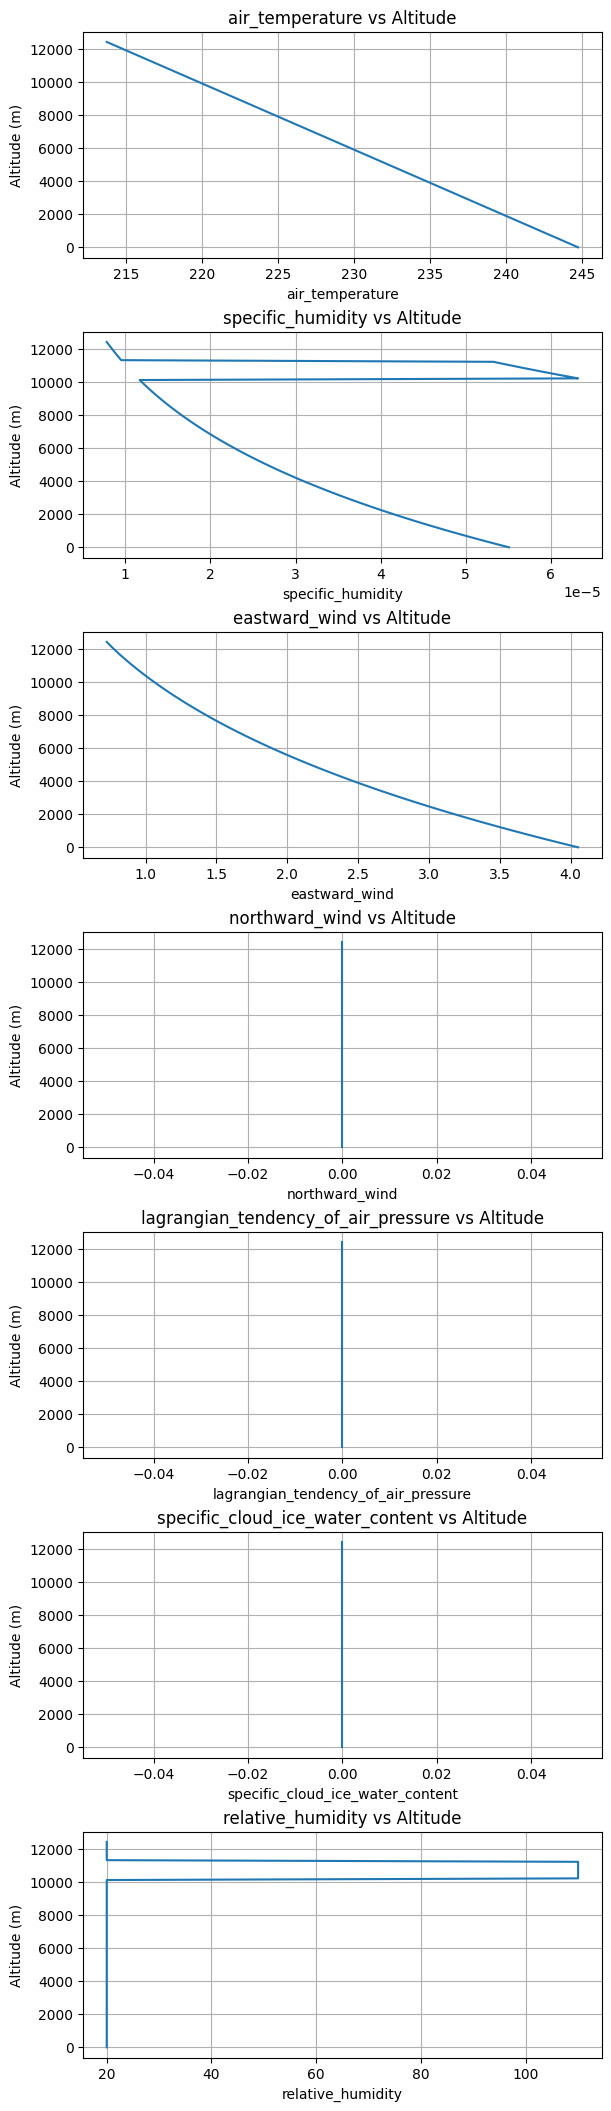

The slope of specific humidity between 10.2-11 km is [-1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05
 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05 -1.0091699e-05] g/kg/m


In [24]:
# Plot each variable in ds_met as a function of altitude for the first lat, lon, and time indices

fig, axs = plt.subplots(len(ds_met.data_vars), 1, figsize=(6, 3 * len(ds_met.data_vars)), constrained_layout=True)

for i, var in enumerate(ds_met.data_vars):
    # Select the first longitude, latitude, and time index for each variable
    data = ds_met[var].isel(longitude=0, latitude=0, time=0)
    axs[i].plot(data.values, ds_met['altitude'].values)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Altitude (m)')
    axs[i].set_title(f"{var} vs Altitude")
    axs[i].grid(True)

plt.show()

mask = (altitudes < 11000) & (altitudes > 10200)
print(f"The slope of specific humidity between 10.2-11 km is {(ds_met['specific_humidity'][0,0,mask,:].values[-1]-ds_met['specific_humidity'][0,0,mask,:].values[0])/(altitudes[mask][-1]-altitudes[mask][0])*1e3} g/kg/m")

## Reformat the met input to work with CoCiP

In [25]:
# Rename the dimensions to match the expected format
new_met = MetDataset(ds_met)

# Run CoCiP

In [26]:
params = {
    "process_emissions": False,
    "verbose_outputs": True,
    "humidity_scaling": ConstantHumidityScaling(rhi_adj=0.98),
    "max_age": np.timedelta64(60, "h"),
    "dt_integration": np.timedelta64(1, "m"),
}
cocip = Cocip(met=new_met, rad=rad, params=params)

In [27]:
fl_out = cocip.eval(source=fl)

In [28]:
fl_out.dataframe.columns

Index(['waypoint', 'longitude', 'latitude', 'Altitude (feet)', 'true_airspeed',
       'mach_number', 'aircraft_mass', 'fuel_flow', 'engine_efficiency',
       'nvpm_ei_n', 'altitude', 'time', 'flight_id', 'level', 'air_pressure',
       'air_temperature', 'specific_humidity', 'u_wind', 'v_wind', 'rhi',
       'tau_cirrus', 'specific_cloud_ice_water_content', 'rho_air', 'sdr',
       'segment_length', 'sin_a', 'cos_a', 'G', 'T_sat_liquid', 'rh',
       'rh_critical_sac', 'sac', 'T_critical_sac', 'width', 'depth', 'rhi_1',
       'air_temperature_1', 'specific_humidity_1', 'altitude_1',
       'persistent_1', 'dT_dz', 'ds_dz', 'dz_max', 'rho_air_1', 'iwc_1',
       'f_surv', 'n_ice_per_m_0', 'n_ice_per_m_1', 'ef', 'contrail_age',
       'sdr_mean', 'sdr_min', 'sdr_max', 'rsr_mean', 'rsr_min', 'rsr_max',
       'olr_mean', 'olr_min', 'olr_max', 'rf_sw_mean', 'rf_sw_min',
       'rf_sw_max', 'rf_lw_mean', 'rf_lw_min', 'rf_lw_max', 'rf_net_mean',
       'rf_net_min', 'rf_net_max', 'cocip']

In [29]:
print(f_surv)

0.776528


In [30]:
fl_out.dataframe

,waypoint,longitude,latitude,Altitude (feet),true_airspeed,mach_number,aircraft_mass,fuel_flow,engine_efficiency,nvpm_ei_n,...,rf_sw_mean,rf_sw_min,rf_sw_max,rf_lw_mean,rf_lw_min,rf_lw_max,rf_net_mean,rf_net_min,rf_net_max,cocip
0,0,-10.070,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.242474,-12.665622,0.0,11.086157,0.229118,15.999912,10.843682,-6.276952,15.999912,1.0
1,1,-10.273,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.234926,-12.379663,0.0,11.289723,0.230805,16.183460,11.054798,-5.954407,16.183460,1.0
2,2,-10.476,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.241951,-12.086165,0.0,11.463422,0.232066,16.331829,11.221471,-5.473710,16.331829,1.0
3,3,-10.680,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.235468,-11.890272,0.0,11.559645,0.232362,16.329548,11.324177,-5.263764,16.329548,1.0
4,4,-10.883,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.229674,-11.467362,0.0,11.600840,0.231662,16.147467,11.371166,-4.692103,16.147467,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,157,-49.002,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.242753,-11.079519,0.0,10.367500,0.171068,14.565540,10.124746,-5.951574,14.565540,1.0
158,158,-49.274,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.239020,-11.593429,0.0,10.423231,0.171806,14.621170,10.184212,-6.637716,14.621170,1.0
159,159,-49.546,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.243077,-11.859619,0.0,10.454582,0.172325,14.669851,10.211505,-6.892298,14.669851,1.0
160,160,-49.818,55.0,36000,237,0.800923,152281.72,1.36986,0.3,2.109915e+14,...,-0.246226,-11.768622,0.0,10.425237,0.171851,14.574593,10.179011,-6.789710,14.574593,1.0


In [31]:
cocip.contrail

,waypoint,flight_id,formation_time,time,age,longitude,latitude,altitude,level,continuous,...,dn_dt_agg,dn_dt_turb,rf_sw,rf_lw,rf_net,persistent,ef,timestep,age_hours,dt_integration
index,,,,,,,,,,,,,,,,,,,,,
0,0,fid,2023-01-01 00:00:00,2023-01-01 00:01:00,0 days 00:00:00,-10.069101,55.0,10654.210466,238.933051,False,...,1.828534e-17,1.506538e-05,0.000000,6.200804,6.200804,True,0.000000e+00,0,0.000000,0 days 00:01:00
1,0,fid,2023-01-01 00:00:00,2023-01-01 00:02:00,0 days 00:02:00,-10.068202,55.0,10654.144791,238.935500,True,...,1.757118e-17,1.440031e-05,0.000000,6.197013,6.197013,True,2.104916e+08,1,0.033333,0 days 00:01:00
2,1,fid,2023-01-01 00:01:00,2023-01-01 00:02:00,0 days 00:00:00,-10.272101,55.0,10654.210466,238.933051,False,...,1.828534e-17,1.506538e-05,0.000000,6.445732,6.445732,True,0.000000e+00,1,0.000000,0 days 00:01:00
3,0,fid,2023-01-01 00:00:00,2023-01-01 00:03:00,0 days 00:03:00,-10.067303,55.0,10654.076886,238.938032,True,...,1.701567e-17,1.380628e-05,0.000000,6.163492,6.163492,True,2.293730e+08,2,0.050000,0 days 00:01:00
4,1,fid,2023-01-01 00:01:00,2023-01-01 00:03:00,0 days 00:02:00,-10.271202,55.0,10654.144791,238.935500,True,...,1.757118e-17,1.440031e-05,0.000000,6.440995,6.440995,True,2.187917e+08,2,0.033333,0 days 00:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93145,160,fid,2023-01-01 02:40:00,2023-01-01 12:14:00,0 days 09:34:00,-49.288661,55.0,10118.904581,259.581843,True,...,8.576880e-19,7.440318e-07,-1.728449,0.697878,-1.030571,True,-2.560618e+09,733,9.566667,0 days 00:01:00
93146,161,fid,2023-01-01 02:41:00,2023-01-01 12:14:00,0 days 00:00:00,-49.471638,55.0,10119.383975,259.562726,False,...,1.800549e-18,8.404965e-07,-2.659245,1.174205,-1.485040,True,0.000000e+00,733,0.000000,0 days 00:01:00
93147,160,fid,2023-01-01 02:40:00,2023-01-01 12:15:00,0 days 09:35:00,-49.287684,55.0,10118.571182,259.595139,True,...,1.314894e-19,6.113152e-07,-0.639853,0.171851,-0.468001,True,-1.514635e+09,734,9.583333,0 days 00:01:00


In [32]:
waypoint = cocip.contrail[cocip.contrail.waypoint == 0]

In [33]:
waypoint.keys()

Index(['waypoint', 'flight_id', 'formation_time', 'time', 'age', 'longitude',
       'latitude', 'altitude', 'level', 'continuous', 'segment_length',
       'sin_a', 'cos_a', 'width', 'depth', 'sigma_yz', 'air_temperature',
       'specific_humidity', 'air_pressure', 'rhi', 'rho_air', 'q_sat',
       'n_ice_per_m', 'iwc', 'u_wind', 'v_wind', 'vertical_velocity',
       'tau_cirrus', 'air_temperature_lower', 'u_wind_lower', 'v_wind_lower',
       'dT_dz', 'ds_dz', 'dsn_dz', 'sdr', 'top_net_solar_radiation', 'rsr',
       'top_net_thermal_radiation', 'olr', 'area_eff', 'plume_mass_per_m',
       'r_ice_vol', 'terminal_fall_speed', 'diffuse_h', 'diffuse_v',
       'n_ice_per_vol', 'tau_contrail', 'dn_dt_agg', 'dn_dt_turb', 'rf_sw',
       'rf_lw', 'rf_net', 'persistent', 'ef', 'timestep', 'age_hours',
       'dt_integration'],
      dtype='object')

In [34]:
# Time 0 is at midnight
print("top_net_thermal_radiation:", waypoint["top_net_thermal_radiation"].iloc[0])
print("top_net_solar_radiation:", waypoint["top_net_solar_radiation"].iloc[0])
print("rf_lw:", waypoint["rf_lw"].iloc[0])
print("rf_sw:", waypoint["rf_sw"].iloc[0])
print("rf_net:", waypoint["rf_net"].iloc[0])
print('ef:', waypoint["ef"].iloc[-1])

top_net_thermal_radiation: -214.96965
top_net_solar_radiation: 0.0
rf_lw: 6.200804
rf_sw: 0.0
rf_net: 6.200804233551025
ef: -1851862621.158145


In [35]:
waypoint

,waypoint,flight_id,formation_time,time,age,longitude,latitude,altitude,level,continuous,...,dn_dt_agg,dn_dt_turb,rf_sw,rf_lw,rf_net,persistent,ef,timestep,age_hours,dt_integration
index,,,,,,,,,,,,,,,,,,,,,
0,0,fid,2023-01-01,2023-01-01 00:01:00,0 days 00:00:00,-10.069101,55.0,10654.210466,238.933051,False,...,1.828534e-17,1.506538e-05,0.000000,6.200804,6.200804,True,0.000000e+00,0,0.000000,0 days 00:01:00
1,0,fid,2023-01-01,2023-01-01 00:02:00,0 days 00:02:00,-10.068202,55.0,10654.144791,238.935500,True,...,1.757118e-17,1.440031e-05,0.000000,6.197013,6.197013,True,2.104916e+08,1,0.033333,0 days 00:01:00
3,0,fid,2023-01-01,2023-01-01 00:03:00,0 days 00:03:00,-10.067303,55.0,10654.076886,238.938032,True,...,1.701567e-17,1.380628e-05,0.000000,6.163492,6.163492,True,2.293730e+08,2,0.050000,0 days 00:01:00
6,0,fid,2023-01-01,2023-01-01 00:04:00,0 days 00:04:00,-10.066404,55.0,10654.006825,238.940645,True,...,1.657262e-17,1.327235e-05,0.000000,6.097523,6.097523,True,2.462024e+08,3,0.066667,0 days 00:01:00
10,0,fid,2023-01-01,2023-01-01 00:05:00,0 days 00:05:00,-10.065505,55.0,10653.934665,238.943336,True,...,1.621277e-17,1.278979e-05,0.000000,6.000681,6.000681,True,2.608285e+08,4,0.083333,0 days 00:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79299,0,fid,2023-01-01,2023-01-01 09:31:00,0 days 09:31:00,-9.543591,55.0,10120.626096,259.513198,True,...,3.993615e-18,9.890633e-07,-4.445918,2.867940,-1.577978,True,-3.413863e+09,570,9.516667,0 days 00:01:00
79461,0,fid,2023-01-01,2023-01-01 09:32:00,0 days 09:32:00,-9.542614,55.0,10119.950787,259.540124,True,...,2.842817e-18,9.189925e-07,-3.692666,2.140634,-1.552032,True,-3.504213e+09,571,9.533333,0 days 00:01:00
79623,0,fid,2023-01-01,2023-01-01 09:33:00,0 days 09:33:00,-9.541638,55.0,10119.372794,259.563172,True,...,1.788340e-18,8.395965e-07,-3.009854,1.558777,-1.451077,True,-3.369719e+09,572,9.550000,0 days 00:01:00


In [36]:
# Convert the waypoint DataFrame to a DataSet
waypoint_ds = waypoint.to_xarray()

In [37]:
if save_data == True:
    # Save the waypoint DataFrame to a .nc file
    waypoint_ds.to_netcdf(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass.nc")
else:
    print("Data not saved. Set save_data = True to save the data.")

Data not saved. Set save_data = True to save the data.


# Plot key variables for a single waypoint

First reported contrail age:  0.0


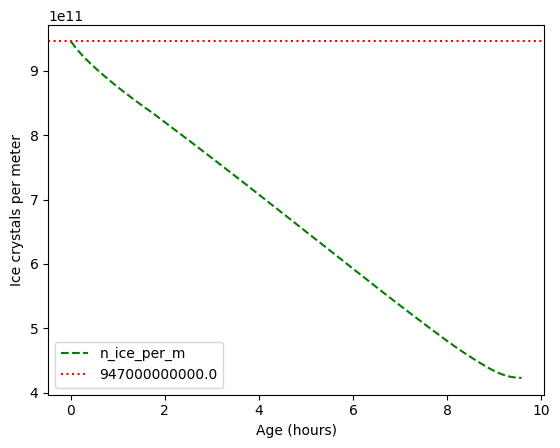

In [38]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "n_ice_per_m",
    ax=ax,
    xlabel="Age (hours)",
    ylabel="Ice crystals per meter",
    color="green",
    legend=False,
    linestyle='--',
)
ax.axhline(N, color='red', linestyle=':', label=str(N))
ax.legend()
print("First reported contrail age: ", waypoint.age_hours.values[0])

In [39]:
print(f"The first value of Ice Crystals per m over the expected value of {N} is {waypoint["n_ice_per_m"][0]/N}")

The first value of Ice Crystals per m over the expected value of 947000000000.0 is 0.9979619130392181


np.float64(307075524.0191016)

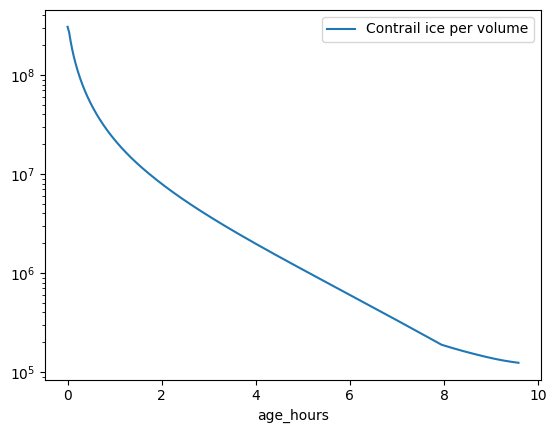

In [40]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "n_ice_per_vol",
    ax=ax,
    label="Contrail ice per volume"
)
ax.set_yscale("log")

waypoint["n_ice_per_vol"].iloc[0]

<Axes: xlabel='age_hours'>

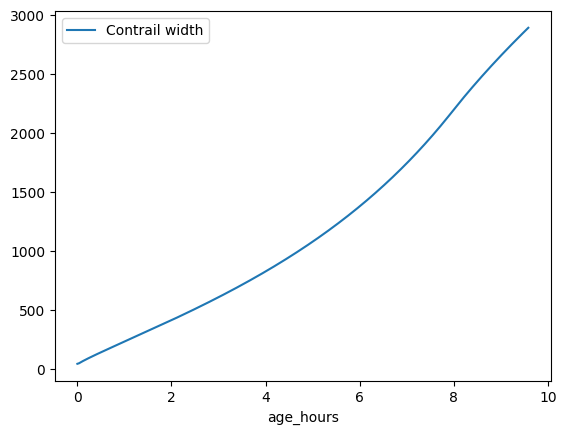

In [41]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "width",

    ax=ax,
    label="Contrail width"
)

<Axes: xlabel='age_hours'>

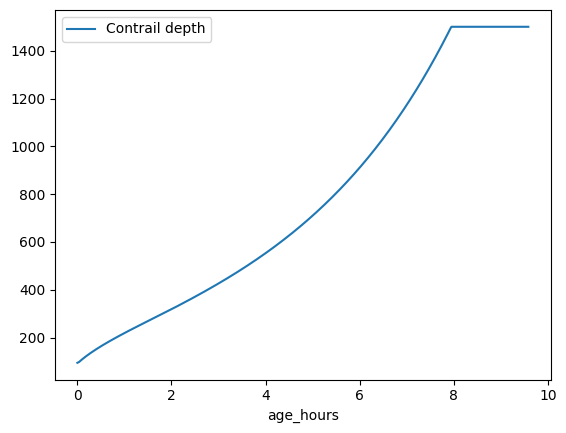

In [42]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "depth",

    ax=ax,
    label="Contrail depth"
)

<Axes: xlabel='Age (hours)', ylabel='Contrail Altitude [m]'>

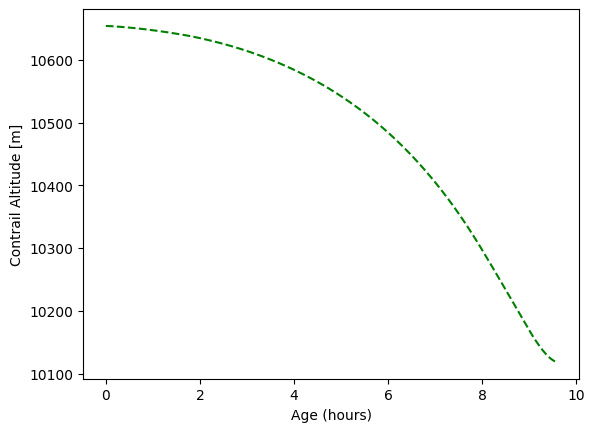

In [43]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "altitude",

    ax=ax,

    xlabel="Age (hours)",
    ylabel="Contrail Altitude [m]",
    color="green",
    linestyle='--',
    legend=False
)

<Axes: xlabel='age_hours'>

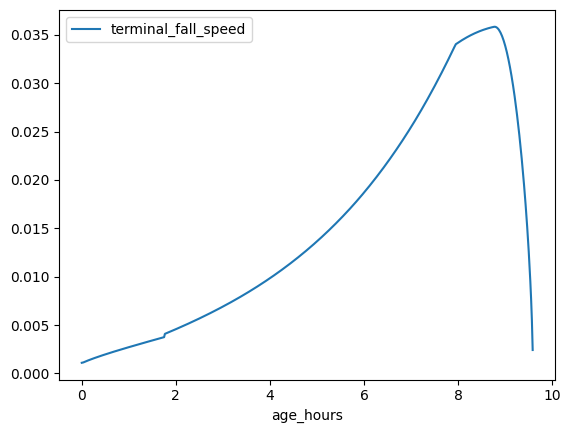

In [44]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "terminal_fall_speed",

    ax=ax,
    label="terminal_fall_speed"
)

<Axes: xlabel='age_hours'>

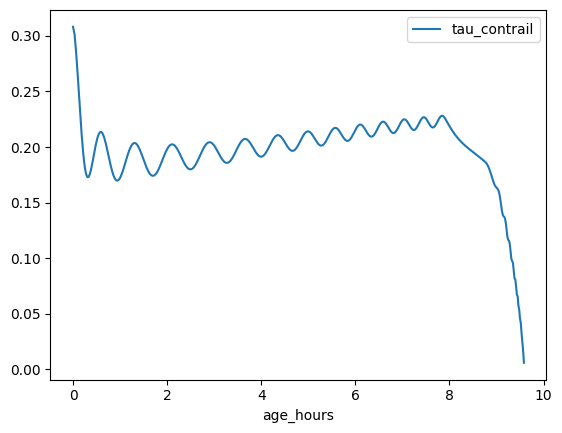

In [45]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "tau_contrail",

    ax=ax,
    label="tau_contrail"
)

<Axes: xlabel='Age (hours)', ylabel='Ice crystal radius (microns)'>

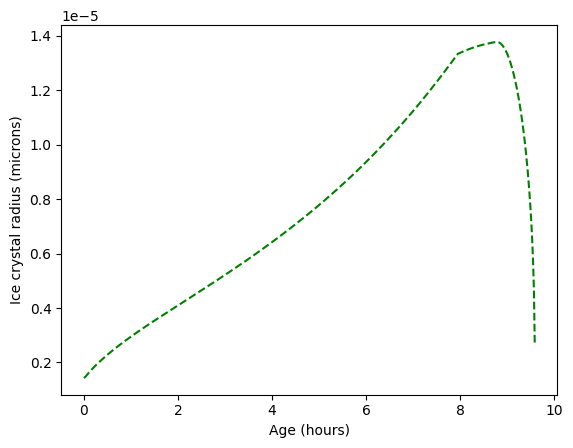

In [46]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "r_ice_vol",

    ax=ax,

    xlabel="Age (hours)",
    ylabel="Ice crystal radius (microns)",
    color="green",
    legend=False,
    linestyle='--',
)

In [47]:
ds_met.close()